# 따릉이 수요 예측 실험 노트북 정리

`resti_dataset_2.csv`를 기준 데이터로 사용하고, `2024_data.parquet`의 시간대별 날씨 정보를 결합한 뒤 LightGBM 기반으로 아래 흐름을 정리한 노트북입니다.

1. 데이터 로딩 및 날씨 결합
2. baseline 비교
3. 하이퍼파라미터 탐색: Grid Search / Random Search / Optuna
4. Feature Selection 리포트: `삭제 필수`, `삭제 고려` 후보 출력
5. 최종 성능 요약 및 시각화

## 0. 라이브러리 및 실행 환경

가급적 노트북 위치와 무관하게 실행되도록 경로를 잡고, Matplotlib 캐시 경로도 작업 폴더 안쪽으로 지정합니다.

In [1]:
from pathlib import Path
import os
import re
import sys
import warnings

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "Data").exists() and (candidate / "Note").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("`Data`와 `Note` 디렉토리를 포함한 프로젝트 루트를 찾지 못했습니다.")

mpl_dir = PROJECT_ROOT / ".mplconfig"
mpl_dir.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(mpl_dir)
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False
try:
    plt.rcParams["font.family"] = "AppleGothic"
except Exception:
    pass

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Python executable: {sys.executable}")
print(f"Optuna version: {optuna.__version__}")

PROJECT_ROOT: /Users/isanghyeon/Documents/EP_cycle_stations
Python executable: /opt/anaconda3/envs/web_scraping/bin/python
Optuna version: 4.7.0


## 1. 실험 설정

기존 노트북의 시간 분할 기준은 유지하고, 탐색은 `grid / random / optuna` 세 가지를 모두 수행합니다.

In [2]:
DATA_DIR = PROJECT_ROOT / "Data"
RESTI_DATA_DIR = DATA_DIR / "Restitutor"
SORT_DATA_DIR = DATA_DIR / "sort_data"
BASE_CSV_PATH = RESTI_DATA_DIR / "resti_dataset_2.csv"
WEATHER_PATH = SORT_DATA_DIR / "2024_data.parquet"
PLOT_OUTPUT_DIR = RESTI_DATA_DIR
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_RUN_STAMP = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
PLOT_SAVE_COUNTER = 0


def _slugify_plot_name(name):
    cleaned = re.sub(r"[^0-9A-Za-z가-힣]+", "_", str(name).strip().lower()).strip("_")
    return cleaned or "figure"


def save_current_figure(name, fig=None):
    global PLOT_SAVE_COUNTER
    fig = fig or plt.gcf()
    PLOT_SAVE_COUNTER += 1
    file_name = f"analystics_01_{PLOT_RUN_STAMP}_{PLOT_SAVE_COUNTER:02d}_{_slugify_plot_name(name)}.png"
    output_path = PLOT_OUTPUT_DIR / file_name
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"시각화 저장 완료: {output_path}")
    return output_path


def save_and_show(name, fig=None):
    fig = fig or plt.gcf()
    save_current_figure(name, fig=fig)
    plt.show()

SEED = 42
TARGET_COL = "총 대여수"
CAT_COL = "station_id"
TIME_COL = "timestamp"
WEATHER_COLS = ["온도", "습도", "불쾌지수", "강수량", "적설량"]
WEATHER_FLAG_COLS = ["rain_flag", "snow_flag"]
PEAK_HOURS = [7, 8, 9, 17, 18, 19]

TRAIN_END = pd.Timestamp("2024-11-01 00:00:00")
VALID_END = pd.Timestamp("2024-12-01 00:00:00")
N_ESTIMATORS = 1500
EARLY_STOPPING_ROUNDS = 80

NUM_RANDOM_TRIALS = 8
NUM_OPTUNA_TRIALS = 8
FEATURE_SELECTION_CANDIDATES = 10
MUST_DROP_THRESHOLD = -0.01
CONSIDER_DROP_THRESHOLD = 0.01
ROLLING_FOLD_COUNT = 3
ROLLING_VALID_MONTHS = 1
HOLDOUT_SCORE_WEIGHT = 0.6
ROLLING_SCORE_WEIGHT = 0.4

BASELINE_PARAMS = {
    "objective": "tweedie",
    "learning_rate": 0.04377660990482319,
    "num_leaves": 84,
    "min_child_samples": 9,
    "subsample": 0.6205257060039263,
    "colsample_bytree": 0.6133415590449772,
    "tweedie_variance_power": 1.2398112718653846,
}
BASELINE_PEAK_WEIGHT = 3.9758747985689578

GRID_SEARCH_SPACE = {
    "objective": ["poisson", "tweedie"],
    "learning_rate": [0.025, 0.035],
    "num_leaves": [64, 96],
    "peak_weight": [3.0, 4.0],
}
GRID_FIXED_PARAMS = {
    "min_child_samples": 7,
    "subsample": 0.65,
    "colsample_bytree": 0.85,
    "reg_alpha": 1.0,
    "reg_lambda": 2.0,
    "min_split_gain": 0.05,
    "tweedie_variance_power": 1.25,
}

print(BASE_CSV_PATH)
print(WEATHER_PATH)


/Users/isanghyeon/Documents/EP_cycle_stations/Data/Restitutor/resti_dataset_2.csv
/Users/isanghyeon/Documents/EP_cycle_stations/Data/sort_data/2024_data.parquet


## 2. 데이터 로딩 및 날씨 시간축 정리

`2024_data.parquet`는 대여 이력 단위로 저장되어 있으므로, 날짜-시간 단위로 날씨를 먼저 집계한 뒤 전체 2024년 시간축에 맞춰 보간합니다.

In [3]:
base_df = pd.read_csv(BASE_CSV_PATH)
base_df[TIME_COL] = pd.to_datetime(
    {
        "year": 2024,
        "month": base_df["month"],
        "day": base_df["date"],
        "hour": base_df["hour"],
    }
)

weather_raw = pd.read_parquet(WEATHER_PATH)
weather_hourly = (
    weather_raw.groupby(["기준_날짜", "시간대"])[WEATHER_COLS]
    .first()
    .reset_index()
)
weather_hourly[TIME_COL] = (
    pd.to_datetime(weather_hourly["기준_날짜"])
    + pd.to_timedelta(weather_hourly["시간대"], unit="h")
)

full_hours = pd.DataFrame(
    {
        TIME_COL: pd.date_range(
            "2024-01-01 00:00:00",
            "2024-12-31 23:00:00",
            freq="h",
        )
    }
)
weather_hourly = (
    full_hours.merge(
        weather_hourly[[TIME_COL, *WEATHER_COLS]],
        on=TIME_COL,
        how="left",
    )
    .sort_values(TIME_COL)
    .reset_index(drop=True)
)

weather_missing_before = weather_hourly[WEATHER_COLS].isna().sum()
weather_hourly[WEATHER_COLS] = weather_hourly[WEATHER_COLS].interpolate(limit_direction="both")
weather_missing_after = weather_hourly[WEATHER_COLS].isna().sum()

missing_summary = pd.DataFrame(
    {
        "missing_before_fill": weather_missing_before,
        "missing_after_fill": weather_missing_after,
    }
)

display(missing_summary)
display(base_df.head())
display(weather_hourly.head())

,missing_before_fill,missing_after_fill
온도,203,0
습도,203,0
불쾌지수,203,0
강수량,203,0
적설량,203,0


,station_id,month,date,hour,weekday,is_weekday,is_restingday,business_ratio,residential_ratio,transit_ratio,...,rolling_mean_6hr,rolling_mean_24hr,rolling_std_24hr,is_rush_hour,is_night,is_daytime,hour_business,hour_transit,총 대여수,timestamp
0,ST-1331,1,1,0,0,0,1,0.0178,0.0160,0.0892,...,NaN,NaN,NaN,0,1,0,0.0000,0.0000,0,2024-01-01 00:00:00
1,ST-1331,1,1,1,0,0,1,0.0178,0.0160,0.0892,...,0.0000,0.0000,NaN,0,1,0,0.0178,0.0892,0,2024-01-01 01:00:00
2,ST-1331,1,1,2,0,0,1,0.0178,0.0160,0.0892,...,0.0000,0.0000,0.0000,0,1,0,0.0356,0.1785,3,2024-01-01 02:00:00
3,ST-1331,1,1,3,0,0,1,0.0178,0.0160,0.0892,...,1.0000,1.0000,1.7321,0,1,0,0.0534,0.2677,1,2024-01-01 03:00:00
4,ST-1331,1,1,4,0,0,1,0.0178,0.0160,0.0892,...,1.0000,1.0000,1.4142,0,1,0,0.0712,0.3569,2,2024-01-01 04:00:00


,timestamp,온도,습도,불쾌지수,강수량,적설량
0,2024-01-01 00:00:00,-2.7000,92.0000,28.4978,0.0000,0.0000
1,2024-01-01 01:00:00,-1.2000,87.0000,31.8534,0.0000,0.0000
2,2024-01-01 02:00:00,-1.2000,88.0000,31.6986,0.0000,0.0000
3,2024-01-01 03:00:00,-1.1000,88.0000,31.8667,0.0000,0.0000
4,2024-01-01 04:00:00,-1.0000,87.0000,32.1877,0.0000,0.0000


## 3. 기준 데이터 + 날씨 병합

시간축 기준으로 병합하고, 강수/적설 여부를 binary flag로 추가합니다.

In [4]:
df = base_df.merge(weather_hourly, on=TIME_COL, how="left")
df["rain_flag"] = (df["강수량"] > 0).astype(int)
df["snow_flag"] = (df["적설량"] > 0).astype(int)
df = df.sort_values([CAT_COL, TIME_COL]).reset_index(drop=True)

raw_base_feature_cols = [c for c in base_df.columns if c not in [TARGET_COL, TIME_COL]]
raw_all_feature_cols = [c for c in df.columns if c not in [TARGET_COL, TIME_COL]]

raw_train_df = df[df[TIME_COL] < TRAIN_END].copy()
raw_valid_df = df[(df[TIME_COL] >= TRAIN_END) & (df[TIME_COL] < VALID_END)].copy()
raw_test_df = df[df[TIME_COL] >= VALID_END].copy()
preprocess_reference_df = raw_train_df.copy()

summary_df = pd.DataFrame(
    [
        {
            "dataset": "base_csv",
            "rows": len(base_df),
            "columns": base_df.shape[1],
            "stations": base_df[CAT_COL].nunique(),
        },
        {
            "dataset": "merged_with_weather",
            "rows": len(df),
            "columns": df.shape[1],
            "stations": df[CAT_COL].nunique(),
        },
        {
            "dataset": "train_reference_for_preprocessing",
            "rows": len(preprocess_reference_df),
            "columns": preprocess_reference_df.shape[1],
            "stations": preprocess_reference_df[CAT_COL].nunique(),
        },
    ]
)

display(summary_df)
display(preprocess_reference_df.head())
display(preprocess_reference_df.isna().sum().sort_values(ascending=False).head(15).to_frame("missing_count"))


,dataset,rows,columns,stations
0,base_csv,26352,30,3
1,merged_with_weather,26352,37,3
2,train_reference_for_preprocessing,21960,37,3


,station_id,month,date,hour,weekday,is_weekday,is_restingday,business_ratio,residential_ratio,transit_ratio,...,hour_transit,총 대여수,timestamp,온도,습도,불쾌지수,강수량,적설량,rain_flag,snow_flag
0,ST-1331,1,1,0,0,0,1,0.0178,0.0160,0.0892,...,0.0000,0,2024-01-01 00:00:00,-2.7000,92.0000,28.4978,0.0000,0.0000,0,0
1,ST-1331,1,1,1,0,0,1,0.0178,0.0160,0.0892,...,0.0892,0,2024-01-01 01:00:00,-1.2000,87.0000,31.8534,0.0000,0.0000,0,0
2,ST-1331,1,1,2,0,0,1,0.0178,0.0160,0.0892,...,0.1785,3,2024-01-01 02:00:00,-1.2000,88.0000,31.6986,0.0000,0.0000,0,0
3,ST-1331,1,1,3,0,0,1,0.0178,0.0160,0.0892,...,0.2677,1,2024-01-01 03:00:00,-1.1000,88.0000,31.8667,0.0000,0.0000,0,0
4,ST-1331,1,1,4,0,0,1,0.0178,0.0160,0.0892,...,0.3569,2,2024-01-01 04:00:00,-1.0000,87.0000,32.1877,0.0000,0.0000,0,0


,missing_count
lag_168hr,1008
lag_24hr,144
lag_3hr,18
rolling_std_24hr,12
lag_2hr,12
rolling_mean_6hr,6
rolling_mean_3hr,6
lag_1hr,6
rolling_mean_24hr,6
총 대여수,0


## 3-1. Feature별 변환 판단용 시각화

아래 표와 그래프는 각 feature를 `log`, `polynomial`, `그대로 사용` 중 어떤 방향으로 검토할지 시각적으로 판단하기 위한 참고 자료입니다.

- `log 후보`: 오른쪽 꼬리가 길고 0 이상 값 위주인 feature
- `polynomial 후보`: 직선보다 곡선 패턴이 더 강해 보이는 feature
- `그대로 확인`: 선형 관계나 이진 분리 성격이 강한 feature

실제 변환은 적용하지 않고, 해석용 자료만 출력합니다.

변환 시각화 제외 feature: ['station_id']
변환 판단 기준 데이터: train split only


,feature,nunique,missing_ratio,skewness,pearson_corr,spearman_corr,poly_signal,visual_hint
0,적설량,21,0.0000,17.7585,-0.0791,-0.1392,-0.0342,log 후보
1,강수량,199,0.0000,15.0825,-0.1104,-0.2533,-0.0714,log 후보
2,lag_168hr,47,0.0459,1.6759,0.5859,0.5304,-0.1863,log 후보
3,lag_24hr,47,0.0066,1.6410,0.6640,0.6073,-0.2029,log 후보
4,lag_1hr,47,0.0003,1.6380,0.6963,0.7050,-0.2568,log 후보
5,lag_2hr,47,0.0005,1.6379,0.5502,0.5729,-0.2184,log 후보
6,lag_3hr,47,0.0008,1.6378,0.4221,0.4484,-0.1689,log 후보
7,rolling_mean_3hr,107,0.0003,1.4557,0.6359,0.6517,-0.2409,log 후보
8,rolling_mean_6hr,180,0.0003,1.3196,0.4934,0.5086,-0.2196,log 후보
9,station_capacity,3,0.0000,0.6857,-0.1054,0.0175,0.0557,polynomial 후보


시각화 저장 완료: /Users/isanghyeon/Documents/EP_cycle_stations/Data/Restitutor/analystics_01_20260318_103946_01_transform_feature_relationships_01_06.png


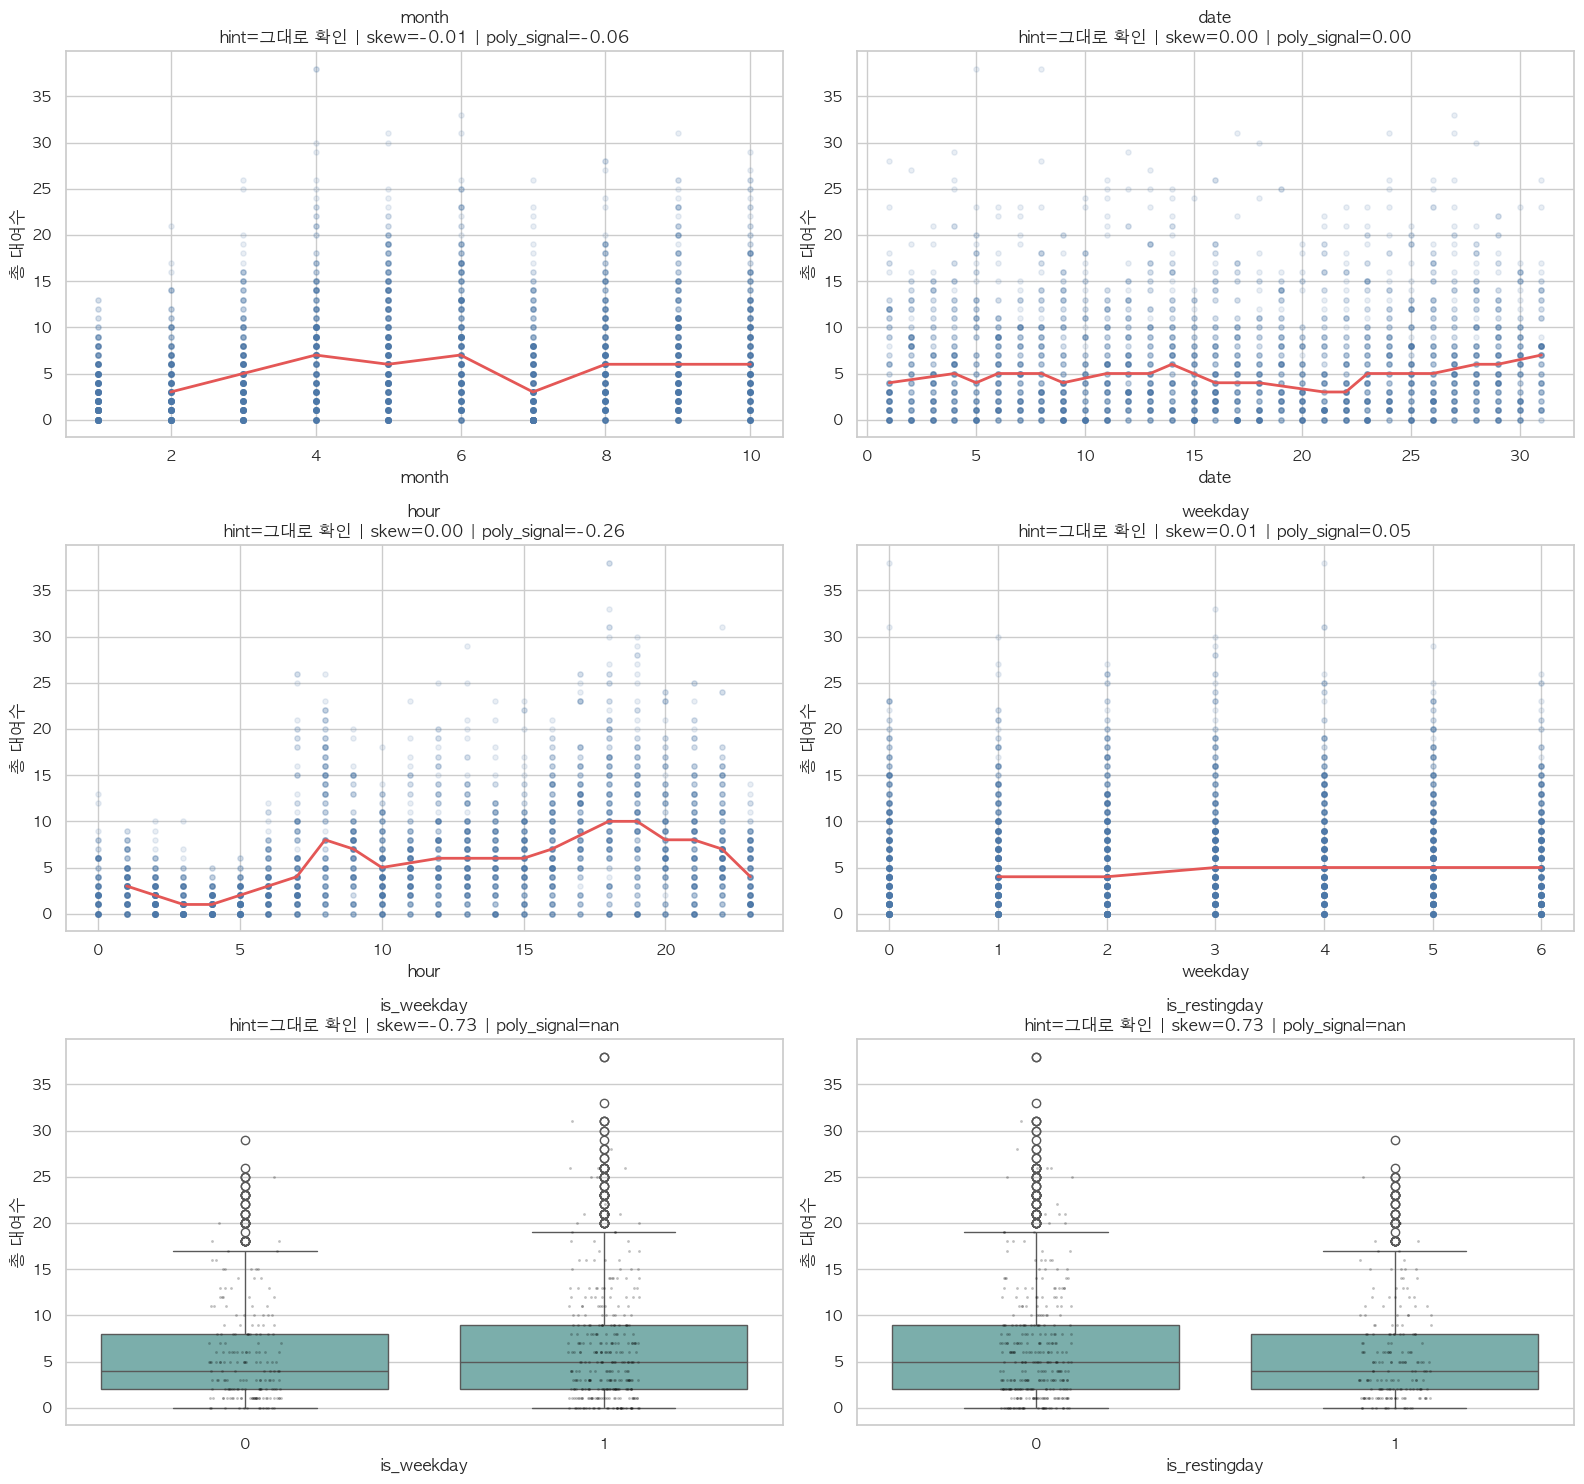

시각화 저장 완료: /Users/isanghyeon/Documents/EP_cycle_stations/Data/Restitutor/analystics_01_20260318_103946_02_transform_feature_relationships_07_12.png


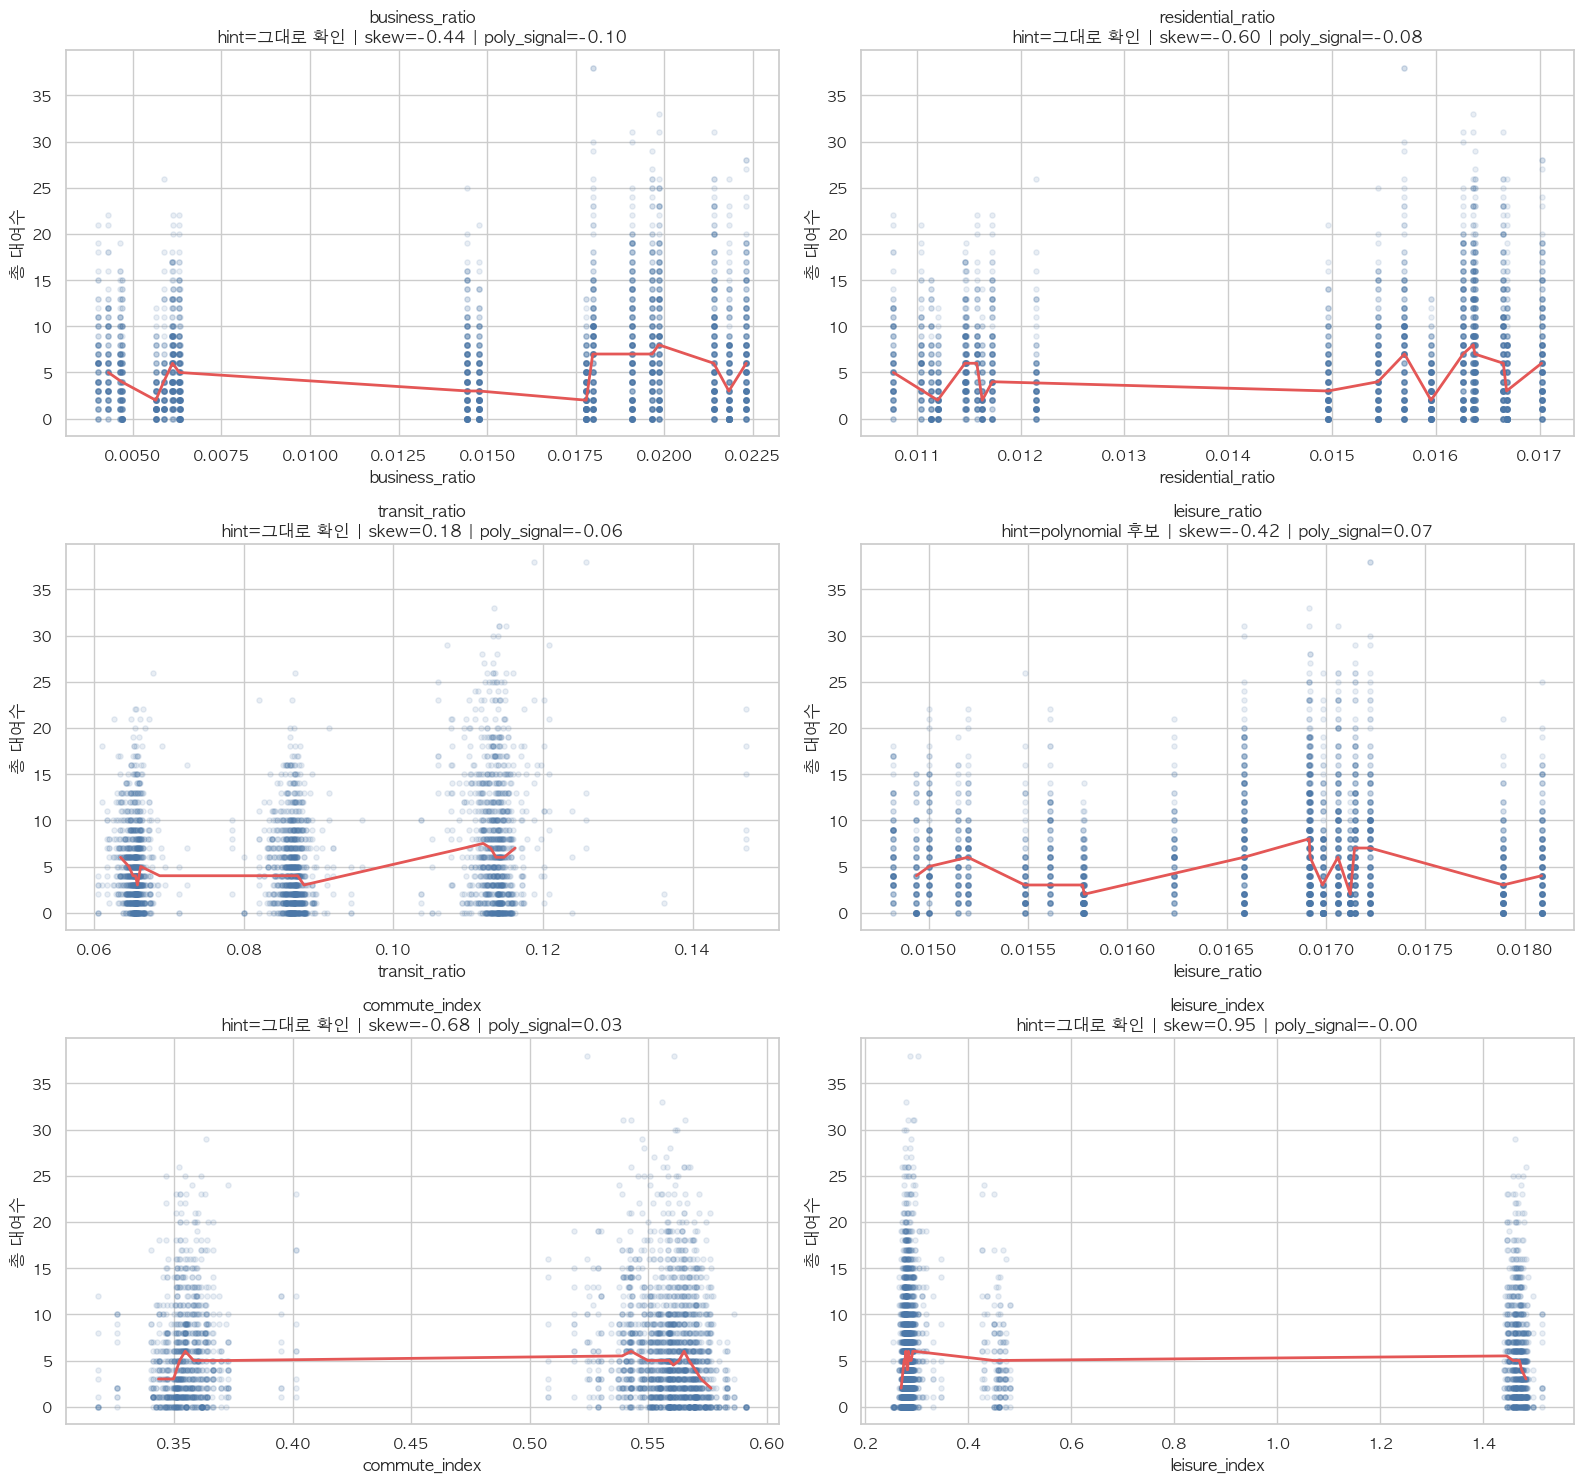

시각화 저장 완료: /Users/isanghyeon/Documents/EP_cycle_stations/Data/Restitutor/analystics_01_20260318_103946_03_transform_feature_relationships_13_18.png


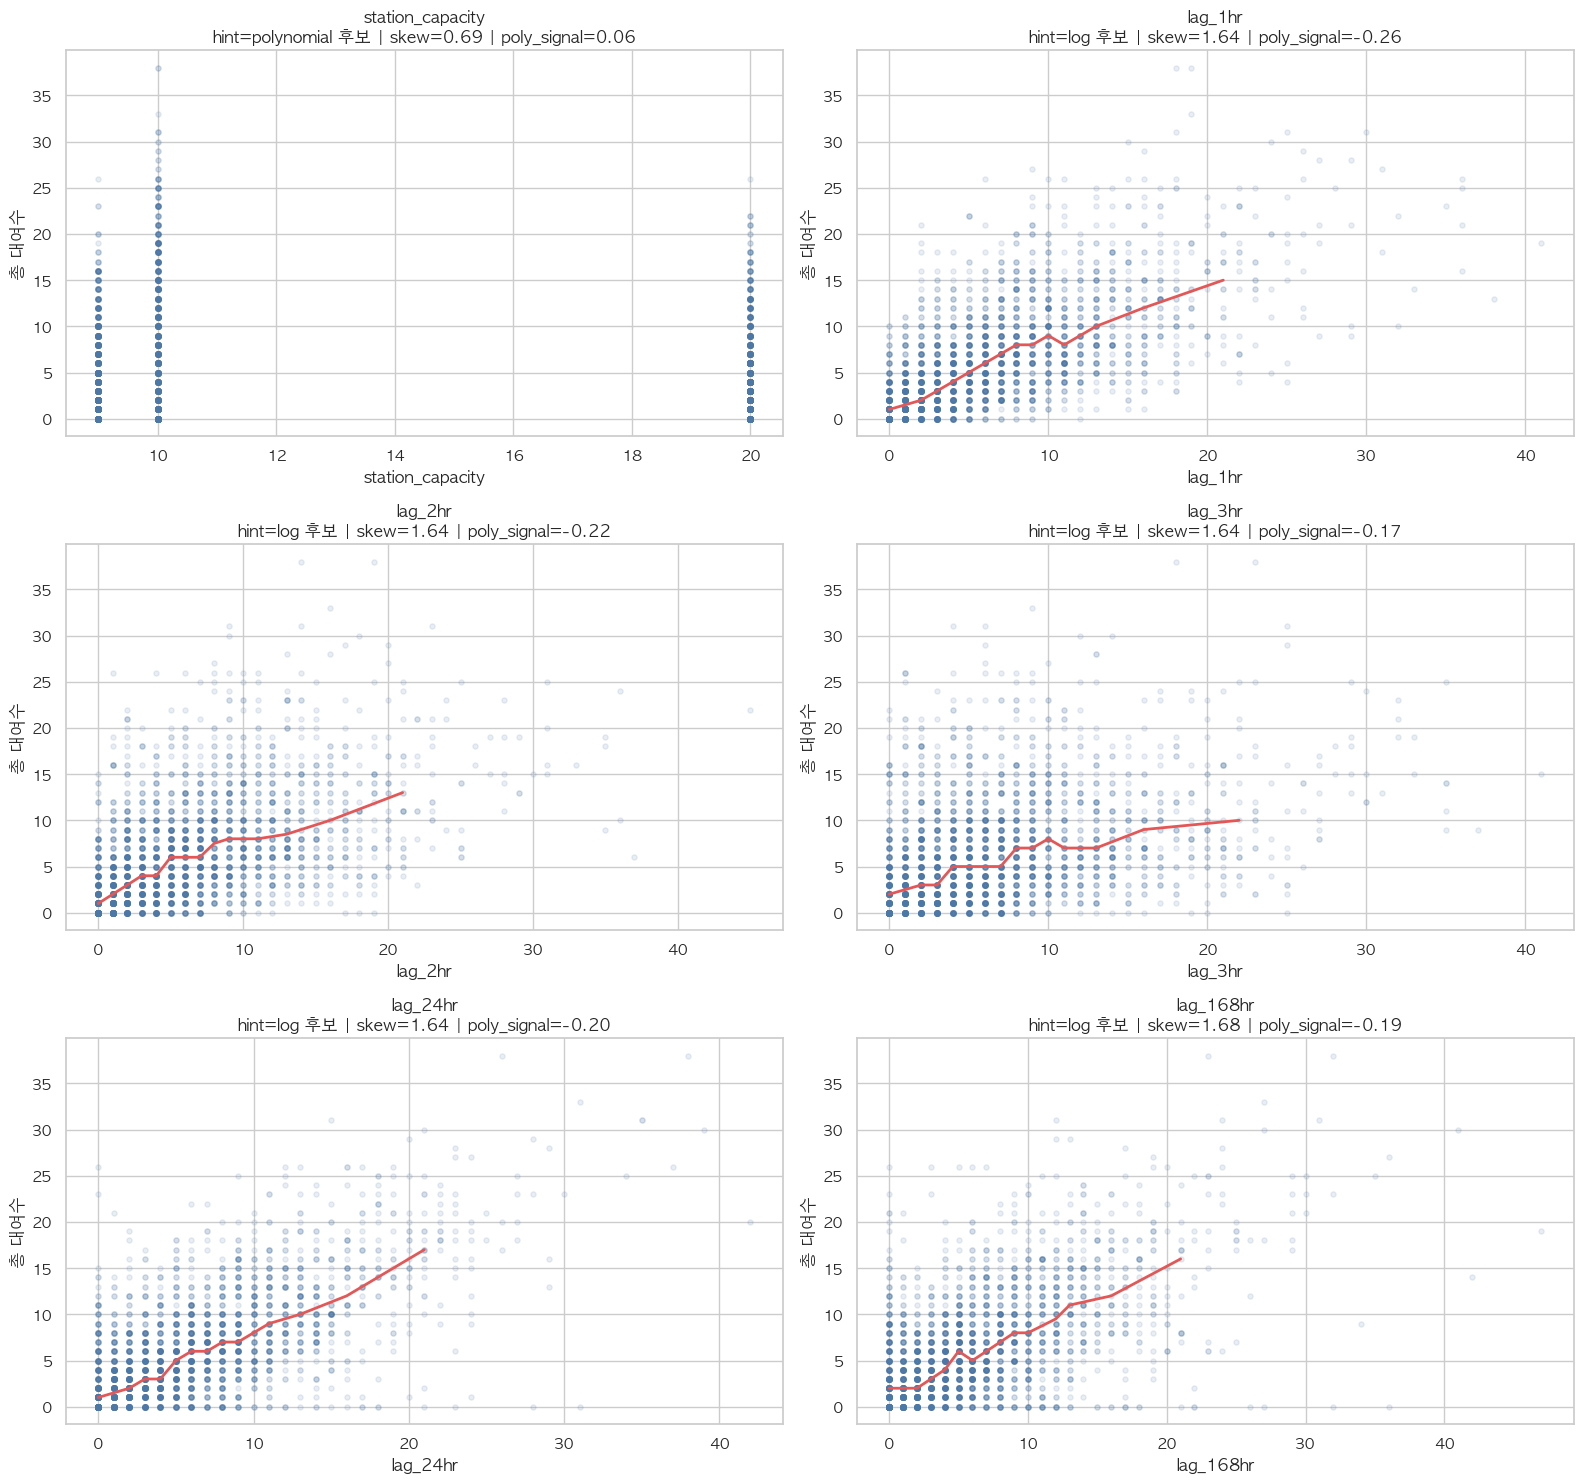

시각화 저장 완료: /Users/isanghyeon/Documents/EP_cycle_stations/Data/Restitutor/analystics_01_20260318_103946_04_transform_feature_relationships_19_24.png


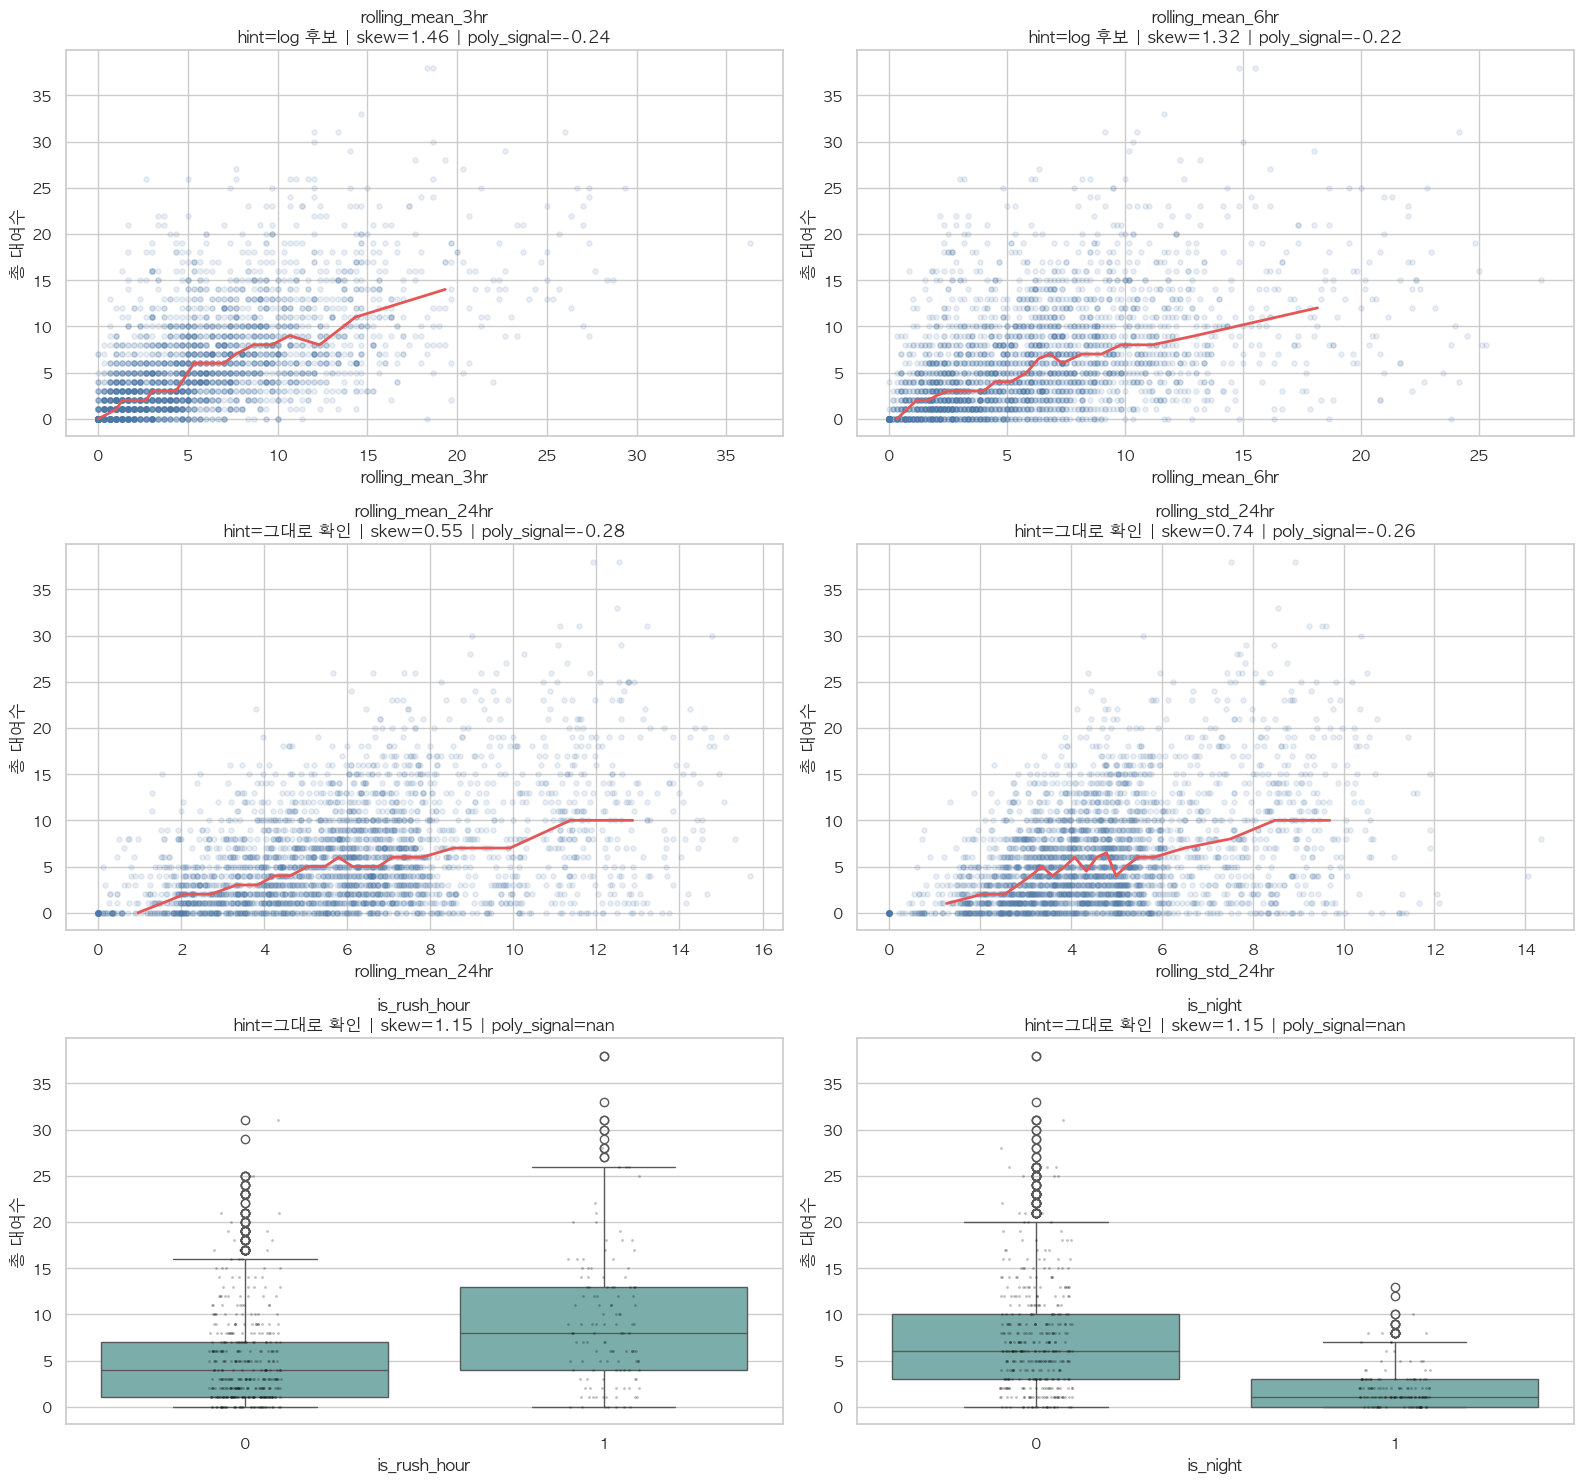

시각화 저장 완료: /Users/isanghyeon/Documents/EP_cycle_stations/Data/Restitutor/analystics_01_20260318_103946_05_transform_feature_relationships_25_30.png


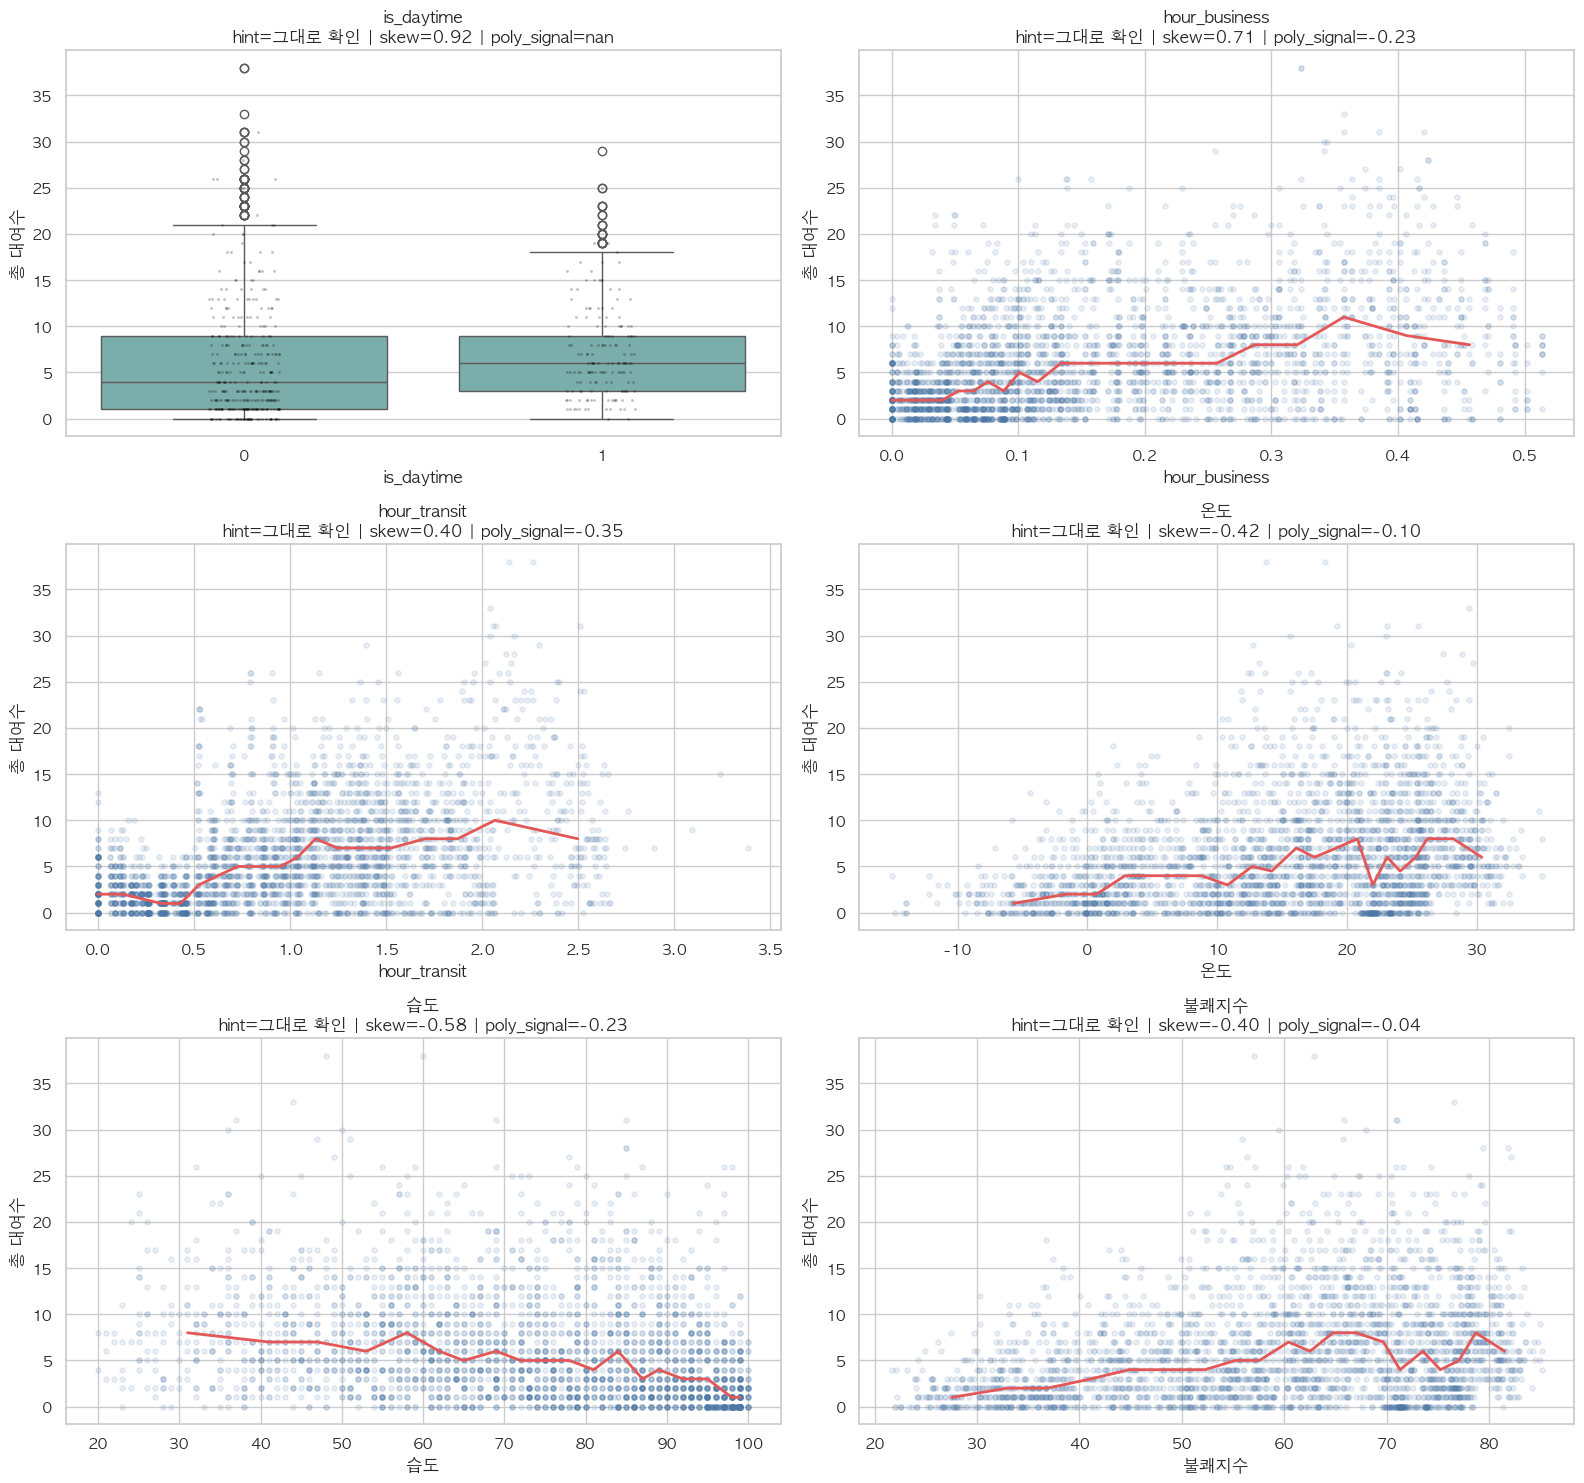

시각화 저장 완료: /Users/isanghyeon/Documents/EP_cycle_stations/Data/Restitutor/analystics_01_20260318_103946_06_transform_feature_relationships_31_34.png


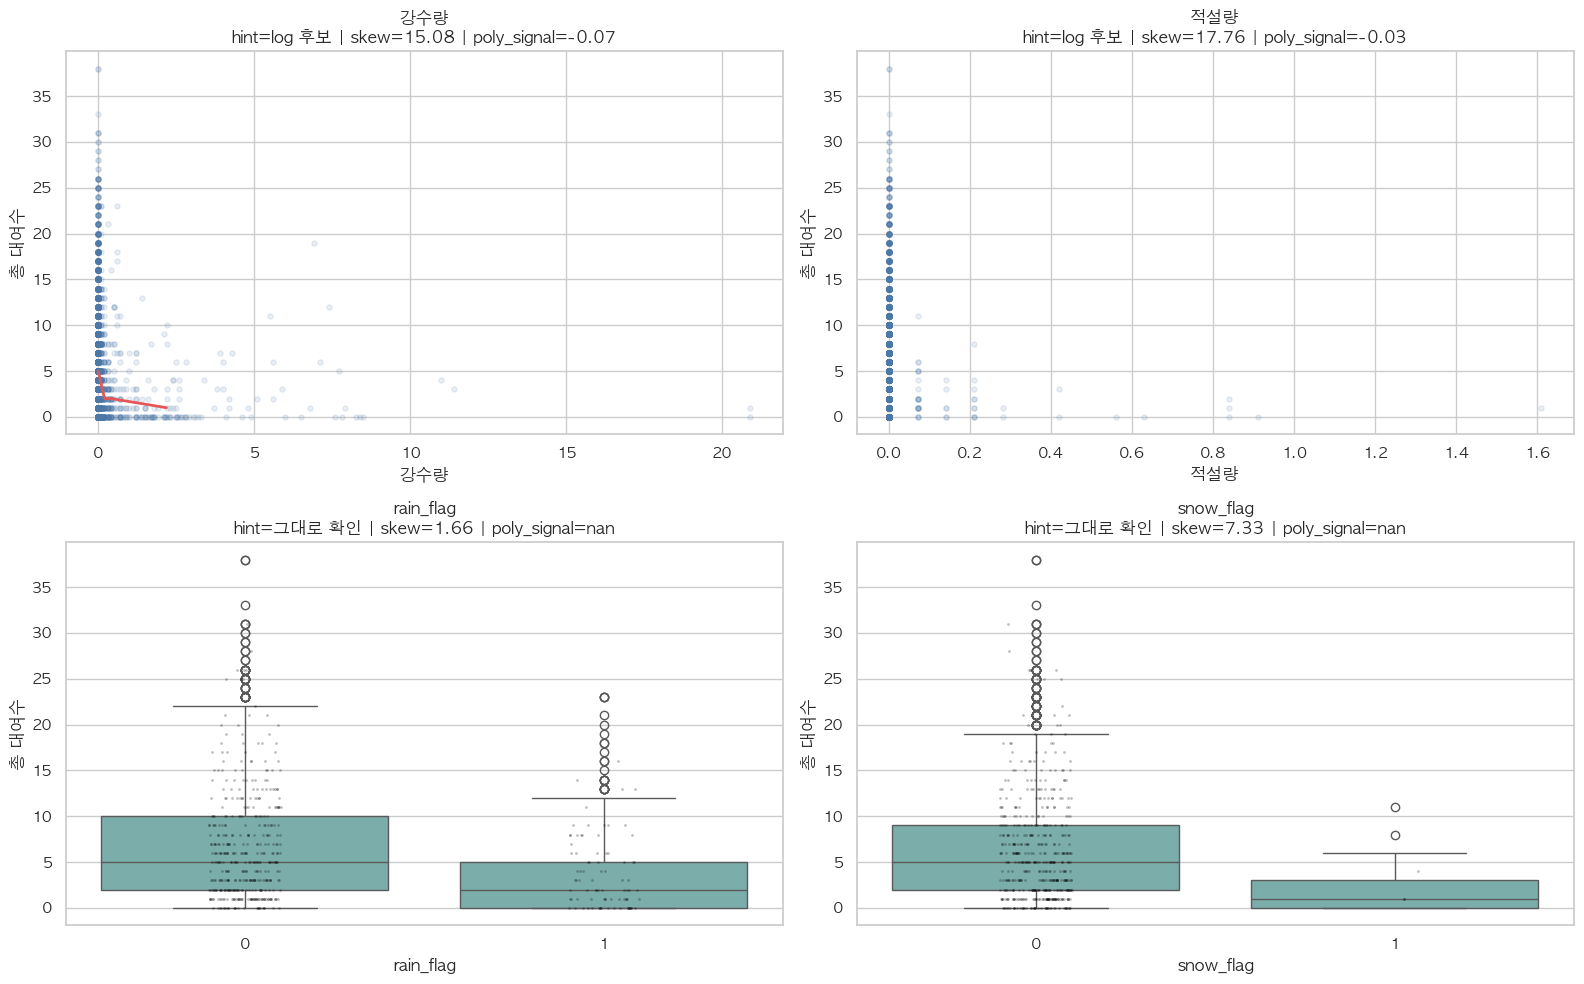

In [5]:
TRANSFORM_PLOT_SAMPLE = min(3000, len(preprocess_reference_df))
TRANSFORM_FEATURES_PER_FIG = 6
TRANSFORM_TREND_BINS = 20

transform_feature_cols = [
    col
    for col in raw_all_feature_cols
    if col != CAT_COL and pd.api.types.is_numeric_dtype(preprocess_reference_df[col])
]
excluded_transform_cols = [CAT_COL]

transform_plot_df = (
    preprocess_reference_df[[*transform_feature_cols, TARGET_COL]]
    .sample(n=TRANSFORM_PLOT_SAMPLE, random_state=SEED)
    .copy()
)


def safe_corr(series_x, series_y, method="pearson"):
    temp = pd.DataFrame({"x": series_x, "y": series_y}).dropna()
    if len(temp) < 5 or temp["x"].nunique() < 2 or temp["y"].nunique() < 2:
        return np.nan
    return temp["x"].corr(temp["y"], method=method)


def calc_poly_signal(series_x, series_y):
    temp = pd.DataFrame({"x": series_x, "y": series_y}).dropna()
    if len(temp) < 5 or temp["x"].nunique() < 3 or temp["y"].nunique() < 2:
        return np.nan

    centered_x = temp["x"] - temp["x"].mean()
    linear_corr = centered_x.corr(temp["y"])
    quadratic_corr = (centered_x**2).corr(temp["y"])
    return abs(quadratic_corr) - abs(linear_corr)


def make_visual_hint(series, skewness, poly_signal):
    valid = series.dropna()
    unique_count = valid.nunique()
    non_negative = (valid >= 0).all()

    if unique_count <= 2:
        return "그대로 확인"
    if pd.notna(skewness) and skewness >= 1.0 and non_negative:
        return "log 후보"
    if pd.notna(poly_signal) and poly_signal >= 0.05:
        return "polynomial 후보"
    return "그대로 확인"


transform_rows = []
for feature in transform_feature_cols:
    feature_series = preprocess_reference_df[feature]
    transform_rows.append(
        {
            "feature": feature,
            "nunique": feature_series.dropna().nunique(),
            "missing_ratio": feature_series.isna().mean(),
            "skewness": feature_series.dropna().skew(),
            "pearson_corr": safe_corr(feature_series, preprocess_reference_df[TARGET_COL], method="pearson"),
            "spearman_corr": safe_corr(feature_series, preprocess_reference_df[TARGET_COL], method="spearman"),
            "poly_signal": calc_poly_signal(feature_series, preprocess_reference_df[TARGET_COL]),
        }
    )

transform_guide = pd.DataFrame(transform_rows)
transform_guide["visual_hint"] = transform_guide.apply(
    lambda row: make_visual_hint(
        preprocess_reference_df[row["feature"]],
        row["skewness"],
        row["poly_signal"],
    ),
    axis=1,
)
transform_guide = transform_guide.sort_values(
    ["visual_hint", "skewness", "poly_signal"],
    ascending=[True, False, False],
).reset_index(drop=True)

print("변환 시각화 제외 feature:", excluded_transform_cols)
print("변환 판단 기준 데이터:", "train split only")
display(transform_guide)

for start in range(0, len(transform_feature_cols), TRANSFORM_FEATURES_PER_FIG):
    subset = transform_feature_cols[start : start + TRANSFORM_FEATURES_PER_FIG]
    ncols = 2
    nrows = int(np.ceil(len(subset) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, feature in zip(axes, subset):
        temp = transform_plot_df[[feature, TARGET_COL]].dropna().copy()
        meta = transform_guide.loc[transform_guide["feature"] == feature].iloc[0]
        unique_count = temp[feature].nunique()

        if unique_count <= 2:
            sns.boxplot(data=temp, x=feature, y=TARGET_COL, ax=ax, color="#72B7B2")
            strip_df = temp.sample(min(500, len(temp)), random_state=SEED)
            sns.stripplot(
                data=strip_df,
                x=feature,
                y=TARGET_COL,
                ax=ax,
                color="black",
                alpha=0.25,
                size=2,
            )
        else:
            ax.scatter(temp[feature], temp[TARGET_COL], alpha=0.12, s=14, color="#4C78A8")
            q = min(TRANSFORM_TREND_BINS, temp[feature].nunique())
            if q >= 5:
                trend_df = temp.sort_values(feature).copy()
                trend_df["_bin"] = pd.qcut(trend_df[feature], q=q, duplicates="drop")
                trend = trend_df.groupby("_bin").agg(
                    feature_mid=(feature, "median"),
                    target_mid=(TARGET_COL, "median"),
                )
                ax.plot(trend["feature_mid"], trend["target_mid"], color="#E45756", linewidth=2)

        ax.set_title(
            f"{feature}\n"
            f"hint={meta['visual_hint']} | skew={meta['skewness']:.2f} | poly_signal={meta['poly_signal']:.2f}"
        )
        ax.set_xlabel(feature)
        ax.set_ylabel(TARGET_COL)

    for ax in axes[len(subset) :]:
        ax.axis("off")

    plt.tight_layout()
    save_and_show(f"transform_feature_relationships_{start + 1:02d}_{start + len(subset):02d}", fig=fig)


## 4. Train / Valid / Test 분리

기존 월 기준 분할은 유지하되, 변환 판단은 train만 사용하고 train 내부에는 rolling validation fold도 함께 구성합니다.

In [6]:
df_raw = df.copy()

AUTO_LOG_FEATURES = transform_guide.loc[
    transform_guide["visual_hint"] == "log 후보",
    "feature",
].tolist()
AUTO_POLY_FEATURES = transform_guide.loc[
    (transform_guide["visual_hint"] == "polynomial 후보")
    & (transform_guide["nunique"] >= 5),
    "feature",
].tolist()
SKIPPED_POLY_LOW_CARDINALITY = transform_guide.loc[
    (transform_guide["visual_hint"] == "polynomial 후보")
    & (transform_guide["nunique"] < 5),
    "feature",
].tolist()


def apply_feature_transforms(frame):
    frame = frame.copy()

    for feature in AUTO_LOG_FEATURES:
        if feature in frame.columns:
            frame[feature] = np.log1p(frame[feature].clip(lower=0))

    for feature in AUTO_POLY_FEATURES:
        if feature in frame.columns:
            frame[f"{feature}_sq"] = frame[feature] ** 2

    frame.drop(columns="month_sq", inplace=True, errors="ignore")
    return frame


train_df = apply_feature_transforms(raw_train_df)
valid_df = apply_feature_transforms(raw_valid_df)
test_df = apply_feature_transforms(raw_test_df)

df = (
    pd.concat([train_df, valid_df, test_df], ignore_index=True)
    .sort_values([CAT_COL, TIME_COL])
    .reset_index(drop=True)
)

base_feature_cols = [
    *raw_base_feature_cols,
    *[f"{feature}_sq" for feature in AUTO_POLY_FEATURES if feature in raw_base_feature_cols],
]
all_feature_cols = [col for col in train_df.columns if col not in [TARGET_COL, TIME_COL]]

base_feature_cols = [col for col in base_feature_cols if col != "month_sq"]
all_feature_cols = [col for col in all_feature_cols if col != "month_sq"]

transform_apply_summary = pd.DataFrame(
    [
        {
            "transform_type": "log1p_applied",
            "feature": feature,
            "result_column": feature,
            "note": "train에서 선정한 규칙을 모든 split에 동일 적용",
        }
        for feature in AUTO_LOG_FEATURES
    ]
    + [
        {
            "transform_type": "polynomial_sq_added",
            "feature": feature,
            "result_column": f"{feature}_sq",
            "note": "train에서 선정한 규칙을 모든 split에 동일 적용",
        }
        for feature in AUTO_POLY_FEATURES
    ]
    + [
        {
            "transform_type": "poly_skipped_low_cardinality",
            "feature": feature,
            "result_column": feature,
            "note": "고유값이 적어 자동 polynomial 적용 제외",
        }
        for feature in SKIPPED_POLY_LOW_CARDINALITY
    ]
)

preview_cols = [TARGET_COL, *AUTO_LOG_FEATURES[:3], *[f"{feature}_sq" for feature in AUTO_POLY_FEATURES[:3]]]
preview_cols = [col for col in preview_cols if col in train_df.columns]

print("적용된 log feature:", AUTO_LOG_FEATURES)
print("적용된 polynomial feature:", AUTO_POLY_FEATURES)
print("polynomial 자동 적용 제외 feature:", SKIPPED_POLY_LOW_CARDINALITY)
display(transform_apply_summary)
display(train_df[preview_cols].head())


적용된 log feature: ['적설량', '강수량', 'lag_168hr', 'lag_24hr', 'lag_1hr', 'lag_2hr', 'lag_3hr', 'rolling_mean_3hr', 'rolling_mean_6hr']
적용된 polynomial feature: ['leisure_ratio']
polynomial 자동 적용 제외 feature: ['station_capacity']


,transform_type,feature,result_column,note
0,log1p_applied,적설량,적설량,train에서 선정한 규칙을 모든 split에 동일 적용
1,log1p_applied,강수량,강수량,train에서 선정한 규칙을 모든 split에 동일 적용
2,log1p_applied,lag_168hr,lag_168hr,train에서 선정한 규칙을 모든 split에 동일 적용
3,log1p_applied,lag_24hr,lag_24hr,train에서 선정한 규칙을 모든 split에 동일 적용
4,log1p_applied,lag_1hr,lag_1hr,train에서 선정한 규칙을 모든 split에 동일 적용
5,log1p_applied,lag_2hr,lag_2hr,train에서 선정한 규칙을 모든 split에 동일 적용
6,log1p_applied,lag_3hr,lag_3hr,train에서 선정한 규칙을 모든 split에 동일 적용
7,log1p_applied,rolling_mean_3hr,rolling_mean_3hr,train에서 선정한 규칙을 모든 split에 동일 적용
8,log1p_applied,rolling_mean_6hr,rolling_mean_6hr,train에서 선정한 규칙을 모든 split에 동일 적용
9,polynomial_sq_added,leisure_ratio,leisure_ratio_sq,train에서 선정한 규칙을 모든 split에 동일 적용


,총 대여수,적설량,강수량,lag_168hr,leisure_ratio_sq
0,0,0.0000,0.0000,NaN,0.0003
1,0,0.0000,0.0000,NaN,0.0003
2,3,0.0000,0.0000,NaN,0.0003
3,1,0.0000,0.0000,NaN,0.0003
4,2,0.0000,0.0000,NaN,0.0003


In [7]:
# month_sq 제거는 모든 split에 동일하게 반영한 상태를 유지한다.
base_feature_cols = [col for col in base_feature_cols if col != "month_sq"]
all_feature_cols = [col for col in all_feature_cols if col != "month_sq"]


## 4. Train / Valid / Test 분리

기존 노트북 기준을 유지해서 11월 이전은 train, 11월은 validation, 12월은 test로 나눕니다.

In [8]:
station_categories = sorted(train_df[CAT_COL].unique())


def build_rolling_folds(frame, fold_count=ROLLING_FOLD_COUNT, valid_months=ROLLING_VALID_MONTHS):
    valid_starts = [TRAIN_END - pd.DateOffset(months=offset) for offset in range(fold_count, 0, -1)]
    folds = []
    rows = []

    for fold_idx, valid_start in enumerate(valid_starts, start=1):
        valid_end = valid_start + pd.DateOffset(months=valid_months)
        fold_train = frame[frame[TIME_COL] < valid_start].copy()
        fold_valid = frame[(frame[TIME_COL] >= valid_start) & (frame[TIME_COL] < valid_end)].copy()
        if fold_train.empty or fold_valid.empty:
            continue

        fold_name = f"rolling_{fold_idx:02d}"
        folds.append(
            {
                "fold": fold_name,
                "train_df": fold_train,
                "valid_df": fold_valid,
            }
        )
        rows.append(
            {
                "fold": fold_name,
                "train_rows": len(fold_train),
                "valid_rows": len(fold_valid),
                "train_start": fold_train[TIME_COL].min(),
                "train_end": fold_train[TIME_COL].max(),
                "valid_start": fold_valid[TIME_COL].min(),
                "valid_end": fold_valid[TIME_COL].max(),
            }
        )

    if not folds:
        raise ValueError("rolling validation fold를 만들지 못했습니다.")

    return folds, pd.DataFrame(rows)


rolling_folds, rolling_fold_summary = build_rolling_folds(train_df)

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": len(train_df),
            "start": train_df[TIME_COL].min(),
            "end": train_df[TIME_COL].max(),
        },
        {
            "split": "valid",
            "rows": len(valid_df),
            "start": valid_df[TIME_COL].min(),
            "end": valid_df[TIME_COL].max(),
        },
        {
            "split": "test",
            "rows": len(test_df),
            "start": test_df[TIME_COL].min(),
            "end": test_df[TIME_COL].max(),
        },
    ]
)

display(split_summary)
display(rolling_fold_summary)


,split,rows,start,end
0,train,21960,2024-01-01,2024-10-31 23:00:00
1,valid,2160,2024-11-01,2024-11-30 23:00:00
2,test,2232,2024-12-01,2024-12-31 23:00:00


,fold,train_rows,valid_rows,train_start,train_end,valid_start,valid_end
0,rolling_01,15336,2232,2024-01-01,2024-07-31 23:00:00,2024-08-01,2024-08-31 23:00:00
1,rolling_02,17568,2160,2024-01-01,2024-08-31 23:00:00,2024-09-01,2024-09-30 23:00:00
2,rolling_03,19728,2232,2024-01-01,2024-09-30 23:00:00,2024-10-01,2024-10-31 23:00:00


## 5. 학습 / 평가 유틸리티

최종 탐색 점수는 holdout validation 점수와 train 내부 rolling validation 점수를 함께 반영하고, test는 마지막에만 평가합니다.

In [9]:
def prepare_xy(frame, features, categories):
    x = frame[features].copy()
    x[CAT_COL] = pd.Categorical(x[CAT_COL], categories=categories)
    y = frame[TARGET_COL].copy()
    return x, y


def make_xy(features):
    x_train, y_train = prepare_xy(train_df, features, station_categories)
    x_valid, y_valid = prepare_xy(valid_df, features, station_categories)
    return x_train, x_valid, y_train, y_valid


def build_lgbm_model(params, n_estimators=N_ESTIMATORS):
    return LGBMRegressor(
        **params,
        n_estimators=n_estimators,
        random_state=SEED,
        n_jobs=-1,
        force_col_wise=True,
        verbosity=-1,
    )


def evaluate_predictions(y_true, pred, peak_mask, prefix):
    peak_mask = np.asarray(peak_mask)
    return {
        f"{prefix}_rmse": mean_squared_error(y_true, pred) ** 0.5,
        f"{prefix}_peak_rmse": mean_squared_error(y_true[peak_mask], pred[peak_mask]) ** 0.5,
        f"{prefix}_offpeak_rmse": mean_squared_error(y_true[~peak_mask], pred[~peak_mask]) ** 0.5,
        f"{prefix}_mae": mean_absolute_error(y_true, pred),
        f"{prefix}_r2": r2_score(y_true, pred),
    }


def make_weighted_score(metrics, prefix):
    return 0.7 * metrics[f"{prefix}_rmse"] + 0.3 * metrics[f"{prefix}_peak_rmse"]


def run_rolling_validation(features, params, peak_weight):
    fold_rows = []

    for fold in rolling_folds:
        fold_categories = sorted(fold["train_df"][CAT_COL].unique())
        x_fold_train, y_fold_train = prepare_xy(fold["train_df"], features, fold_categories)
        x_fold_valid, y_fold_valid = prepare_xy(fold["valid_df"], features, fold_categories)

        peak_mask_train = x_fold_train["hour"].isin(PEAK_HOURS)
        peak_mask_valid = x_fold_valid["hour"].isin(PEAK_HOURS)

        fold_model = build_lgbm_model(params)
        fold_model.fit(
            x_fold_train,
            y_fold_train,
            sample_weight=np.where(peak_mask_train, peak_weight, 1.0),
            eval_set=[(x_fold_valid, y_fold_valid)],
            eval_metric="rmse",
            callbacks=[
                lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                lgb.log_evaluation(0),
            ],
            categorical_feature=[CAT_COL],
        )

        pred_fold_valid = np.clip(
            fold_model.predict(x_fold_valid, num_iteration=fold_model.best_iteration_),
            0,
            None,
        )
        fold_metrics = evaluate_predictions(y_fold_valid, pred_fold_valid, peak_mask_valid, prefix="rolling_valid")
        fold_rows.append(
            {
                "fold": fold["fold"],
                **fold_metrics,
                "rolling_score": make_weighted_score(fold_metrics, "rolling_valid"),
            }
        )

    fold_df = pd.DataFrame(fold_rows)
    rolling_metrics = {
        "rolling_valid_rmse": fold_df["rolling_valid_rmse"].mean(),
        "rolling_valid_peak_rmse": fold_df["rolling_valid_peak_rmse"].mean(),
        "rolling_valid_offpeak_rmse": fold_df["rolling_valid_offpeak_rmse"].mean(),
        "rolling_valid_mae": fold_df["rolling_valid_mae"].mean(),
        "rolling_valid_r2": fold_df["rolling_valid_r2"].mean(),
        "rolling_score": fold_df["rolling_score"].mean(),
        "rolling_fold_count": len(fold_df),
    }
    return rolling_metrics, fold_df


def run_experiment(features, params, peak_weight, label):
    x_train, x_valid, y_train, y_valid = make_xy(features)
    peak_mask_train = x_train["hour"].isin(PEAK_HOURS)
    peak_mask_valid = x_valid["hour"].isin(PEAK_HOURS)

    model = build_lgbm_model(params)
    model.fit(
        x_train,
        y_train,
        sample_weight=np.where(peak_mask_train, peak_weight, 1.0),
        eval_set=[(x_valid, y_valid)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(0),
        ],
        categorical_feature=[CAT_COL],
    )

    pred_valid = np.clip(model.predict(x_valid, num_iteration=model.best_iteration_), 0, None)
    valid_metrics = evaluate_predictions(y_valid, pred_valid, peak_mask_valid, prefix="valid")
    rolling_metrics, rolling_fold_metrics = run_rolling_validation(features, params, peak_weight)

    score = (
        HOLDOUT_SCORE_WEIGHT * make_weighted_score(valid_metrics, "valid")
        + ROLLING_SCORE_WEIGHT * rolling_metrics["rolling_score"]
    )

    metrics = {
        "label": label,
        "n_features": len(features),
        **valid_metrics,
        **rolling_metrics,
        "best_iteration": model.best_iteration_,
        "score": score,
    }

    return {
        "label": label,
        "features": list(features),
        "params": dict(params),
        "peak_weight": float(peak_weight),
        "model": model,
        "metrics": metrics,
        "pred_valid": pred_valid,
        "rolling_fold_metrics": rolling_fold_metrics,
    }


def compact_result_row(run, method, trial_id):
    return {
        "method": method,
        "trial": trial_id,
        "peak_weight": run["peak_weight"],
        **run["params"],
        **run["metrics"],
    }


def plot_search_results(results_df, method_name):
    plot_df = results_df.copy().sort_values("score").reset_index(drop=True)
    display_cols = [
        "trial",
        "score",
        "valid_rmse",
        "valid_peak_rmse",
        "rolling_valid_rmse",
        "rolling_valid_peak_rmse",
        "peak_weight",
        "objective",
        "learning_rate",
        "num_leaves",
        "min_child_samples",
    ]
    display(plot_df[display_cols])

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    top_df = plot_df.head(min(10, len(plot_df))).copy()
    top_df["trial"] = top_df["trial"].astype(str)

    sns.barplot(data=top_df, x="score", y="trial", ax=axes[0], palette="viridis")
    axes[0].set_title(f"{method_name}: Lower Score Is Better")
    axes[0].set_xlabel("score")
    axes[0].set_ylabel("trial")

    sns.scatterplot(
        data=plot_df,
        x="valid_rmse",
        y="rolling_valid_rmse",
        hue="score",
        size="score",
        palette="viridis_r",
        ax=axes[1],
        legend=False,
    )
    axes[1].set_title(f"{method_name}: Holdout vs Rolling RMSE")
    axes[1].set_xlabel("valid_rmse")
    axes[1].set_ylabel("rolling_valid_rmse")

    plt.tight_layout()
    save_and_show(f"{method_name}_search_results", fig=fig)


def fit_final_test_model(base_run):
    train_valid_df = (
        pd.concat([train_df, valid_df], ignore_index=True)
        .sort_values([CAT_COL, TIME_COL])
        .reset_index(drop=True)
    )
    train_valid_categories = sorted(train_valid_df[CAT_COL].unique())

    x_train_valid, y_train_valid = prepare_xy(train_valid_df, base_run["features"], train_valid_categories)
    x_test, y_test = prepare_xy(test_df, base_run["features"], train_valid_categories)

    peak_mask_train_valid = x_train_valid["hour"].isin(PEAK_HOURS)
    peak_mask_test = x_test["hour"].isin(PEAK_HOURS)
    final_n_estimators = int(base_run["metrics"].get("best_iteration") or N_ESTIMATORS)

    final_model = build_lgbm_model(base_run["params"], n_estimators=final_n_estimators)
    final_model.fit(
        x_train_valid,
        y_train_valid,
        sample_weight=np.where(peak_mask_train_valid, base_run["peak_weight"], 1.0),
        categorical_feature=[CAT_COL],
    )

    pred_test = np.clip(final_model.predict(x_test), 0, None)
    test_metrics = evaluate_predictions(y_test, pred_test, peak_mask_test, prefix="test")

    return {
        "model": final_model,
        "pred_test": pred_test,
        "metrics": test_metrics,
        "train_valid_df": train_valid_df,
    }


## 6. Baseline 비교

같은 baseline 파라미터로 원본 피처셋과 날씨 결합 피처셋을 비교해서, 날씨 정보가 실제로 도움이 되는지 먼저 확인합니다.

In [10]:
baseline_without_weather = run_experiment(
    base_feature_cols,
    BASELINE_PARAMS,
    BASELINE_PEAK_WEIGHT,
    label="baseline_without_weather",
)
baseline_with_weather = run_experiment(
    all_feature_cols,
    BASELINE_PARAMS,
    BASELINE_PEAK_WEIGHT,
    label="baseline_with_weather",
)

baseline_comparison = pd.DataFrame(
    [baseline_without_weather["metrics"], baseline_with_weather["metrics"]]
).sort_values("score")

display(baseline_comparison)
print(f"날씨 결합 후 Holdout Valid RMSE 개선: {baseline_without_weather['metrics']['valid_rmse'] - baseline_with_weather['metrics']['valid_rmse']:.4f}")
print(f"날씨 결합 후 Holdout Peak RMSE 개선: {baseline_without_weather['metrics']['valid_peak_rmse'] - baseline_with_weather['metrics']['valid_peak_rmse']:.4f}")
print(f"날씨 결합 후 Rolling RMSE 개선: {baseline_without_weather['metrics']['rolling_valid_rmse'] - baseline_with_weather['metrics']['rolling_valid_rmse']:.4f}")


,label,n_features,valid_rmse,valid_peak_rmse,valid_offpeak_rmse,valid_mae,valid_r2,rolling_valid_rmse,rolling_valid_peak_rmse,rolling_valid_offpeak_rmse,rolling_valid_mae,rolling_valid_r2,rolling_score,rolling_fold_count,best_iteration,score
1,baseline_with_weather,36,2.7493,3.2128,2.5763,2.0251,0.6822,3.3331,4.4014,2.8858,2.4310,0.6867,3.6536,3,245,3.1944
0,baseline_without_weather,29,2.8919,3.4484,2.6808,2.1493,0.6484,3.3746,4.4697,2.9108,2.4602,0.6794,3.7031,3,172,3.3165


날씨 결합 후 Holdout Valid RMSE 개선: 0.1426
날씨 결합 후 Holdout Peak RMSE 개선: 0.2356
날씨 결합 후 Rolling RMSE 개선: 0.0415


## 7. Grid Search

Grid Search는 강한 baseline 근처의 조합만 촘촘하게 확인하고, 결과 표와 시각화만 출력합니다.

,trial,score,valid_rmse,valid_peak_rmse,rolling_valid_rmse,rolling_valid_peak_rmse,peak_weight,objective,learning_rate,num_leaves,min_child_samples
0,8,3.1827,2.7190,3.1627,3.3494,4.4470,3.0000,poisson,0.0350,64,7
1,2,3.1847,2.7253,3.1735,3.3479,4.4285,3.0000,tweedie,0.0250,64,7
2,12,3.1857,2.7137,3.1478,3.3655,4.4752,3.0000,poisson,0.0350,96,7
3,3,3.1910,2.7291,3.1760,3.3625,4.4301,4.0000,tweedie,0.0250,64,7
4,9,3.1918,2.7304,3.1501,3.3707,4.4519,4.0000,poisson,0.0350,64,7
5,4,3.1929,2.7229,3.1855,3.3567,4.4668,3.0000,poisson,0.0250,96,7
6,10,3.1950,2.7424,3.2000,3.3485,4.4137,3.0000,tweedie,0.0350,64,7
7,0,3.1988,2.7422,3.2225,3.3417,4.4277,3.0000,poisson,0.0250,64,7
8,1,3.2004,2.7391,3.1908,3.3654,4.4443,4.0000,poisson,0.0250,64,7
9,13,3.2023,2.7288,3.1750,3.3753,4.4971,4.0000,poisson,0.0350,96,7


시각화 저장 완료: /Users/isanghyeon/Documents/EP_cycle_stations/Data/Restitutor/analystics_01_20260318_103946_07_grid_search_search_results.png


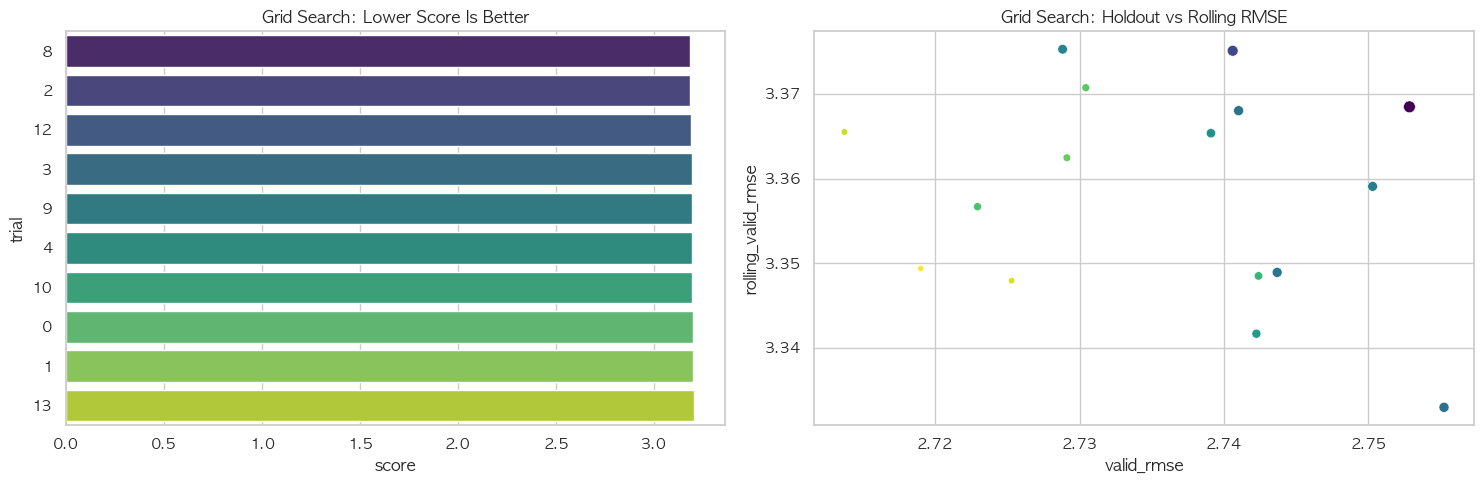

,grid_best
peak_weight,3.0000
min_child_samples,7
subsample,0.6500
colsample_bytree,0.8500
reg_alpha,1.0000
reg_lambda,2.0000
min_split_gain,0.0500
objective,poisson
learning_rate,0.0350
num_leaves,64


In [11]:
def make_grid_params(combo):
    peak_weight = combo["peak_weight"]
    params = dict(GRID_FIXED_PARAMS)
    params.update(
        {
            "objective": combo["objective"],
            "learning_rate": combo["learning_rate"],
            "num_leaves": combo["num_leaves"],
            "min_child_samples": GRID_FIXED_PARAMS["min_child_samples"],
            "subsample": GRID_FIXED_PARAMS["subsample"],
            "colsample_bytree": GRID_FIXED_PARAMS["colsample_bytree"],
            "reg_alpha": GRID_FIXED_PARAMS["reg_alpha"],
            "reg_lambda": GRID_FIXED_PARAMS["reg_lambda"],
            "min_split_gain": GRID_FIXED_PARAMS["min_split_gain"],
        }
    )
    if params["objective"] != "tweedie":
        params.pop("tweedie_variance_power", None)
    return params, peak_weight


def run_grid_search(features):
    rows = []
    best_run = None
    for trial_idx, combo in enumerate(ParameterGrid(GRID_SEARCH_SPACE)):
        params, peak_weight = make_grid_params(combo)
        run = run_experiment(features, params, peak_weight, label=f"grid_{trial_idx:02d}")
        rows.append(compact_result_row(run, method="grid", trial_id=trial_idx))
        if best_run is None or run["metrics"]["score"] < best_run["metrics"]["score"]:
            best_run = run
    result_df = pd.DataFrame(rows).sort_values("score").reset_index(drop=True)
    return best_run, result_df


grid_best_run, grid_results = run_grid_search(all_feature_cols)
plot_search_results(grid_results, method_name="Grid Search")
display(pd.Series({"peak_weight": grid_best_run["peak_weight"], **grid_best_run["params"], **grid_best_run["metrics"]}).to_frame("grid_best"))

## 8. Random Search

Random Search는 더 넓은 탐색 범위에서 다양한 조합을 샘플링하고, 결과 표와 시각화만 출력합니다.

,trial,score,valid_rmse,valid_peak_rmse,rolling_valid_rmse,rolling_valid_peak_rmse,peak_weight,objective,learning_rate,num_leaves,min_child_samples
0,1,3.1620,2.7142,3.1553,3.3102,4.3937,1.2234,tweedie,0.0255,92,25
1,5,3.1871,2.7494,3.2023,3.3250,4.3741,3.7326,tweedie,0.0182,56,42
2,6,3.1886,2.7181,3.1728,3.3606,4.4581,3.2215,poisson,0.0326,86,7
3,2,3.1956,2.7553,3.1897,3.3338,4.4230,1.1533,tweedie,0.0372,136,14
4,3,3.1981,2.7532,3.2255,3.3258,4.4165,1.4547,tweedie,0.0138,125,42
5,0,3.2047,2.7737,3.2988,3.2967,4.3578,1.4484,regression,0.0249,129,28
6,4,3.2067,2.7499,3.2317,3.3471,4.4409,2.3562,tweedie,0.0160,88,36
7,7,3.2125,2.8006,3.2603,3.3220,4.3266,3.9869,regression,0.0316,36,35


시각화 저장 완료: /Users/isanghyeon/Documents/EP_cycle_stations/Data/Restitutor/analystics_01_20260318_103946_08_random_search_search_results.png


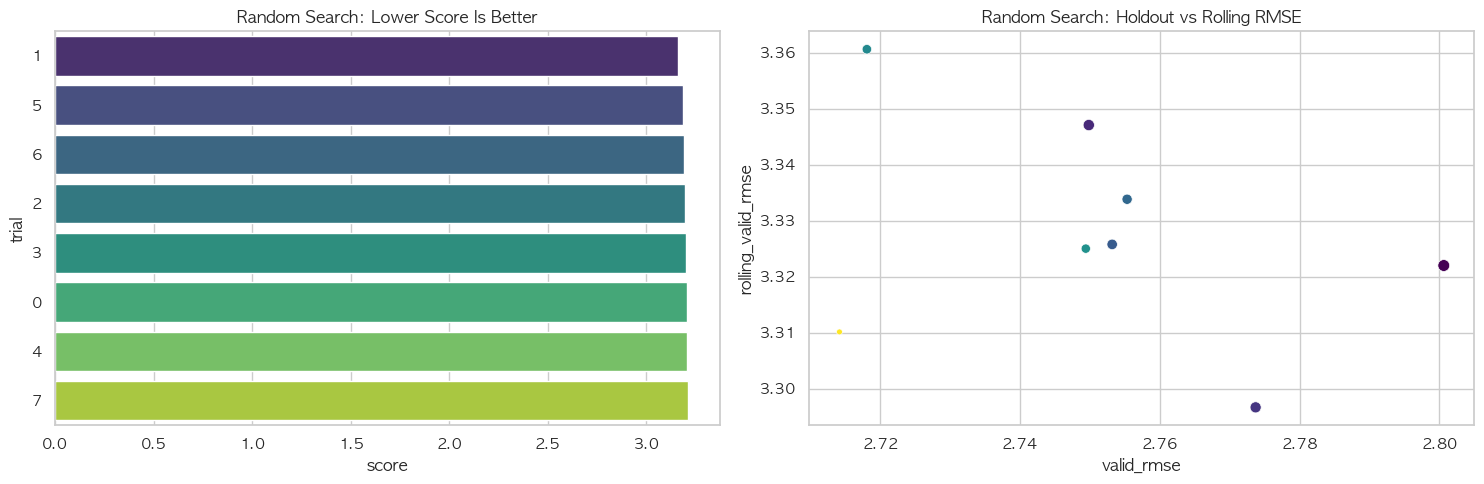

,random_best
peak_weight,1.2234
objective,tweedie
learning_rate,0.0255
num_leaves,92
min_child_samples,25
subsample,0.9707
colsample_bytree,0.8575
reg_alpha,2.0569
reg_lambda,1.7737
min_split_gain,0.0454


In [12]:
def sample_random_params(rng):
    objective = str(rng.choice(["regression", "poisson", "tweedie"]))
    params = {
        "objective": objective,
        "learning_rate": float(np.exp(rng.uniform(np.log(0.01), np.log(0.08)))),
        "num_leaves": int(rng.integers(24, 160)),
        "min_child_samples": int(rng.integers(5, 60)),
        "subsample": float(rng.uniform(0.6, 1.0)),
        "colsample_bytree": float(rng.uniform(0.6, 1.0)),
        "reg_alpha": float(rng.uniform(0.0, 2.5)),
        "reg_lambda": float(rng.uniform(0.0, 4.0)),
        "min_split_gain": float(rng.uniform(0.0, 0.2)),
    }
    if objective == "tweedie":
        params["tweedie_variance_power"] = float(rng.uniform(1.1, 1.6))
    return params


def run_random_search(features, n_trials=NUM_RANDOM_TRIALS, seed=SEED):
    rng = np.random.default_rng(seed)
    rows = []
    best_run = None
    for trial_idx in range(n_trials):
        params = sample_random_params(rng)
        peak_weight = float(rng.uniform(1.0, 4.5))
        run = run_experiment(features, params, peak_weight, label=f"random_{trial_idx:02d}")
        rows.append(compact_result_row(run, method="random", trial_id=trial_idx))
        if best_run is None or run["metrics"]["score"] < best_run["metrics"]["score"]:
            best_run = run
    result_df = pd.DataFrame(rows).sort_values("score").reset_index(drop=True)
    return best_run, result_df


random_best_run, random_results = run_random_search(all_feature_cols)
plot_search_results(random_results, method_name="Random Search")
display(pd.Series({"peak_weight": random_best_run["peak_weight"], **random_best_run["params"], **random_best_run["metrics"]}).to_frame("random_best"))

## 9. Optuna Search

Optuna는 TPE sampler를 사용해 같은 평가 기준으로 탐색하고, 결과 표와 시각화만 출력합니다.

In [ ]:
def run_optuna_search(features, n_trials=NUM_OPTUNA_TRIALS, seed=SEED):
    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    trial_runs = {}

    def objective(trial):
        objective_name = trial.suggest_categorical("objective", ["regression", "poisson", "tweedie"])
        params = {
            "objective": objective_name,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 24, 160),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 4.0),
            "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.2),
        }
        if objective_name == "tweedie":
            params["tweedie_variance_power"] = trial.suggest_float("tweedie_variance_power", 1.1, 1.6)

        peak_weight = trial.suggest_float("peak_weight", 1.0, 4.5)
        run = run_experiment(features, params, peak_weight, label=f"optuna_{trial.number:02d}")
        trial_runs[trial.number] = run
        return run["metrics"]["score"]

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    rows = [compact_result_row(run, method="optuna", trial_id=trial_num) for trial_num, run in trial_runs.items()]
    result_df = pd.DataFrame(rows).sort_values("score").reset_index(drop=True)
    best_run = trial_runs[study.best_trial.number]
    return best_run, result_df, study


optuna_best_run, optuna_results, optuna_study = run_optuna_search(all_feature_cols)
plot_search_results(optuna_results, method_name="Optuna Search")
display(pd.Series({"peak_weight": optuna_best_run["peak_weight"], **optuna_best_run["params"], **optuna_best_run["metrics"]}).to_frame("optuna_best"))

## 10. 탐색 방법별 결과 비교

세 방법의 최고 성능과 전체 탐색 분포를 한 번에 비교합니다.

In [ ]:
search_best_summary = pd.DataFrame(
    [
        {"search_method": "grid", **grid_best_run["metrics"], "peak_weight": grid_best_run["peak_weight"]},
        {"search_method": "random", **random_best_run["metrics"], "peak_weight": random_best_run["peak_weight"]},
        {"search_method": "optuna", **optuna_best_run["metrics"], "peak_weight": optuna_best_run["peak_weight"]},
    ]
).sort_values("score").reset_index(drop=True)

overall_best_run = min([grid_best_run, random_best_run, optuna_best_run], key=lambda run: run["metrics"]["score"])
all_search_results = pd.concat([grid_results, random_results, optuna_results], ignore_index=True)
overall_best_method = search_best_summary.iloc[0]["search_method"]

display(search_best_summary)
display(pd.Series({"best_search_method": overall_best_method, "peak_weight": overall_best_run["peak_weight"], **overall_best_run["params"], **overall_best_run["metrics"]}).to_frame("overall_best"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=search_best_summary, x="search_method", y="score", ax=axes[0], palette="Set2")
axes[0].set_title("Best Score by Search Method")
axes[0].set_xlabel("search_method")
axes[0].set_ylabel("score")

sns.scatterplot(
    data=all_search_results,
    x="valid_rmse",
    y="rolling_valid_rmse",
    hue="method",
    style="method",
    s=90,
    ax=axes[1],
)
axes[1].set_title("Holdout vs Rolling RMSE by Trial")
axes[1].set_xlabel("valid_rmse")
axes[1].set_ylabel("rolling_valid_rmse")

plt.tight_layout()
save_and_show("search_method_comparison", fig=fig)


## 11. Feature Selection 리포트

직접 피처를 삭제하지 않고, 현재 최적 모델 기준으로 낮은 중요도 후보를 하나씩 제거했을 때 성능이 어떻게 변하는지 측정해서 `삭제 필수`, `삭제 고려` 후보만 분류합니다.

In [ ]:
def classify_feature_candidate(row):
    if (
        row["score_delta"] <= MUST_DROP_THRESHOLD
        and row["valid_rmse_delta"] <= 0
        and row["valid_peak_rmse_delta"] <= 0
    ):
        return "삭제 필수"
    if row["score_delta"] <= CONSIDER_DROP_THRESHOLD:
        return "삭제 고려"
    return "유지 권장"


def build_feature_selection_report(base_run, n_candidates=FEATURE_SELECTION_CANDIDATES):
    base_score = base_run["metrics"]["score"]
    base_valid_rmse = base_run["metrics"]["valid_rmse"]
    base_peak_rmse = base_run["metrics"]["valid_peak_rmse"]
    base_rolling_rmse = base_run["metrics"]["rolling_valid_rmse"]
    base_rolling_peak_rmse = base_run["metrics"]["rolling_valid_peak_rmse"]

    importance = pd.Series(
        base_run["model"].feature_importances_,
        index=base_run["features"],
    ).sort_values()
    candidates = [feature for feature in importance.index if feature != CAT_COL][:n_candidates]

    rows = []
    for rank, feature in enumerate(candidates, start=1):
        reduced_features = [col for col in base_run["features"] if col != feature]
        drop_run = run_experiment(
            reduced_features,
            base_run["params"],
            base_run["peak_weight"],
            label=f"drop_{feature}",
        )
        rows.append(
            {
                "candidate_rank": rank,
                "feature": feature,
                "importance": importance[feature],
                "drop_score": drop_run["metrics"]["score"],
                "score_delta": drop_run["metrics"]["score"] - base_score,
                "valid_rmse_delta": drop_run["metrics"]["valid_rmse"] - base_valid_rmse,
                "valid_peak_rmse_delta": drop_run["metrics"]["valid_peak_rmse"] - base_peak_rmse,
                "rolling_valid_rmse_delta": drop_run["metrics"]["rolling_valid_rmse"] - base_rolling_rmse,
                "rolling_valid_peak_rmse_delta": drop_run["metrics"]["rolling_valid_peak_rmse"] - base_rolling_peak_rmse,
            }
        )

    report = pd.DataFrame(rows).sort_values(["score_delta", "importance"]).reset_index(drop=True)
    report["판정"] = report.apply(classify_feature_candidate, axis=1)
    must_drop = report[report["판정"] == "삭제 필수"].reset_index(drop=True)
    consider_drop = report[report["판정"] == "삭제 고려"].reset_index(drop=True)
    return importance, report, must_drop, consider_drop


feature_importance = pd.Series(
    overall_best_run["model"].feature_importances_,
    index=overall_best_run["features"],
).sort_values(ascending=False)

low_importance, feature_selection_report, must_drop_features, consider_drop_features = build_feature_selection_report(overall_best_run)

display(feature_selection_report)
print("삭제 필수 후보:")
display(must_drop_features if not must_drop_features.empty else pd.DataFrame(columns=feature_selection_report.columns))
print("삭제 고려 후보:")
display(consider_drop_features if not consider_drop_features.empty else pd.DataFrame(columns=feature_selection_report.columns))


## 12. Feature Selection 시각화

낮은 중요도 후보와 제거 시 점수 변화를 같이 확인해서, 어떤 피처가 우선 검토 대상인지 빠르게 볼 수 있게 합니다.

In [ ]:
plot_report = feature_selection_report.copy()
plot_report["color"] = plot_report["판정"].map(
    {
        "삭제 필수": "#E45756",
        "삭제 고려": "#F58518",
        "유지 권장": "#4C78A8",
    }
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

importance_view = plot_report.sort_values("importance", ascending=True)
axes[0].barh(importance_view["feature"], importance_view["importance"], color="#72B7B2")
axes[0].set_title("Low-Importance Candidate Features")
axes[0].set_xlabel("importance")
axes[0].set_ylabel("feature")

score_view = plot_report.sort_values("score_delta", ascending=True)
axes[1].barh(score_view["feature"], score_view["score_delta"], color=score_view["color"])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].axvline(MUST_DROP_THRESHOLD, color="#E45756", linestyle="--", linewidth=1)
axes[1].axvline(CONSIDER_DROP_THRESHOLD, color="#F58518", linestyle="--", linewidth=1)
axes[1].set_title("Score Delta After Dropping Each Feature")
axes[1].set_xlabel("score_delta (negative is better)")
axes[1].set_ylabel("feature")

plt.tight_layout()
save_and_show("feature_selection_candidates", fig=fig)

## 13. 최종 요약

Feature는 실제로 삭제하지 않고, 탐색 결과가 가장 좋은 모델을 최종 모델로 둡니다.

In [ ]:
final_run = overall_best_run
final_test_run = fit_final_test_model(final_run)

summary_rows = [
    {"stage": "baseline_without_weather", **baseline_without_weather["metrics"]},
    {"stage": "baseline_with_weather", **baseline_with_weather["metrics"]},
    {"stage": "grid_best", **grid_best_run["metrics"]},
    {"stage": "random_best", **random_best_run["metrics"]},
    {"stage": "optuna_best", **optuna_best_run["metrics"]},
    {"stage": "final_selected_model", **final_run["metrics"]},
]
summary_table = pd.DataFrame(summary_rows).sort_values("score").reset_index(drop=True)
sealed_test_summary = pd.Series(final_test_run["metrics"], name="sealed_test").to_frame("value")

display(summary_table)
display(pd.Series(final_run["params"], name="final_params").to_frame("value"))
display(sealed_test_summary)
print(f"final peak_weight: {final_run['peak_weight']:.4f}")
print(f"rolling fold count: {int(final_run['metrics']['rolling_fold_count'])}")
print(f"삭제 필수 개수: {len(must_drop_features)}")
print(f"삭제 고려 개수: {len(consider_drop_features)}")


## 14. 최종 모델 시각화

Validation 세트 기준으로 중요도, 산점도, 잔차 분포, 실제값-예측값 흐름을 확인합니다.

In [ ]:
final_pred_valid = final_run["pred_valid"]
y_valid = valid_df[TARGET_COL].to_numpy()
residuals = y_valid - final_pred_valid

valid_plot = valid_df[[TIME_COL, CAT_COL, TARGET_COL]].copy()
valid_plot["prediction"] = final_pred_valid
sample_plot = valid_plot.head(168)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

feature_importance.head(15).sort_values().plot(kind="barh", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Top 15 Feature Importance")
axes[0, 0].set_xlabel("Gain Importance")

axes[0, 1].scatter(y_valid, final_pred_valid, alpha=0.25, s=16)
axis_min = min(y_valid.min(), final_pred_valid.min())
axis_max = max(y_valid.max(), final_pred_valid.max())
axes[0, 1].plot([axis_min, axis_max], [axis_min, axis_max], color="red")
axes[0, 1].set_title("Validation: Actual vs Prediction")
axes[0, 1].set_xlabel("Actual")
axes[0, 1].set_ylabel("Prediction")

axes[1, 0].hist(residuals, bins=40, color="#F58518", alpha=0.85)
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].set_xlabel("Residual")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].plot(sample_plot[TIME_COL], sample_plot[TARGET_COL], label="Actual", linewidth=2)
axes[1, 1].plot(sample_plot[TIME_COL], sample_plot["prediction"], label="Prediction", linewidth=2)
axes[1, 1].set_title("Validation Sample (First 168 rows)")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend()

plt.tight_layout()
save_and_show("final_model_diagnostics", fig=fig)

## 15. 선택 저장

원하면 날씨가 결합된 학습용 데이터셋을 별도 CSV로 저장할 수 있게 옵션만 둡니다.

In [ ]:
SAVE_PROCESSED_DATA = False

if SAVE_PROCESSED_DATA:
    output_path = RESTI_DATA_DIR / "resti_dataset_2_weather.csv"
    df.drop(columns=[TIME_COL]).to_csv(output_path, index=False)
    print(f"저장 완료: {output_path}")
else:
    print("SAVE_PROCESSED_DATA=False 이므로 파일 저장은 건너뜁니다.")

In [ ]:
train_valid_rows = len(final_test_run["train_valid_df"])
y_test = test_df[TARGET_COL].to_numpy()
pred_test = final_test_run["pred_test"]

test_metrics = final_test_run["metrics"]
print("Train+Valid rows used for final fit:", train_valid_rows)
print("Test rows:", len(test_df))
print("Sealed Test RMSE:", test_metrics["test_rmse"])
print("Sealed Test Peak RMSE:", test_metrics["test_peak_rmse"])
print("Sealed Test Offpeak RMSE:", test_metrics["test_offpeak_rmse"])
print("Sealed Test MAE:", test_metrics["test_mae"])
print("Sealed Test R2:", test_metrics["test_r2"])


In [ ]:
df.to_csv(RESTI_DATA_DIR / "resti_dataset_3.csv", index=False)